# importing the necessary libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from wordcloud import WordCloud

# Loading the dataset and extracting basic details

In [15]:
df = pd.read_csv("student_feedback.csv")
df

,Unnamed: 0,Student ID,Well versed with the subject,Explains concepts in an understandable way,Use of presentations,Degree of difficulty of assignments,Solves doubts willingly,Structuring of the course,Provides support for students going above and beyond,Course recommendation based on relevance
0,0,340,5,2,7,6,9,2,1,8
1,1,253,6,5,8,6,2,1,2,9
2,2,680,7,7,6,5,4,2,3,1
3,3,806,9,6,7,1,5,9,4,6
4,4,632,8,10,8,4,6,6,9,9
...,...,...,...,...,...,...,...,...,...,...
996,996,55,8,7,6,2,5,7,7,9
997,997,913,5,5,6,5,6,7,6,1
998,998,199,9,5,8,3,8,1,1,2
999,999,539,10,2,7,4,3,4,10,1


In [17]:
print(df.columns)

Index(['Unnamed: 0', 'Student ID', 'Well versed with the subject',
       'Explains concepts in an understandable way', 'Use of presentations',
       'Degree of difficulty of assignments', 'Solves doubts willingly',
       'Structuring of the course',
       'Provides support for students going above and beyond',
       'Course recommendation based on relevance'],
      dtype='object')


In [19]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 10 columns):
 #   Column                                                Non-Null Count  Dtype
---  ------                                                --------------  -----
 0   Unnamed: 0                                            1001 non-null   int64
 1   Student ID                                            1001 non-null   int64
 2   Well versed with the subject                          1001 non-null   int64
 3   Explains concepts in an understandable way            1001 non-null   int64
 4   Use of presentations                                  1001 non-null   int64
 5   Degree of difficulty of assignments                   1001 non-null   int64
 6   Solves doubts willingly                               1001 non-null   int64
 7   Structuring of the course                             1001 non-null   int64
 8   Provides support for students going above and beyond  1001 non-null   int64
 9

# Drop unnecessary column

In [22]:
df = df.drop(columns=["Unnamed: 0"])

In [24]:
df

,Student ID,Well versed with the subject,Explains concepts in an understandable way,Use of presentations,Degree of difficulty of assignments,Solves doubts willingly,Structuring of the course,Provides support for students going above and beyond,Course recommendation based on relevance
0,340,5,2,7,6,9,2,1,8
1,253,6,5,8,6,2,1,2,9
2,680,7,7,6,5,4,2,3,1
3,806,9,6,7,1,5,9,4,6
4,632,8,10,8,4,6,6,9,9
...,...,...,...,...,...,...,...,...,...
996,55,8,7,6,2,5,7,7,9
997,913,5,5,6,5,6,7,6,1
998,199,9,5,8,3,8,1,1,2
999,539,10,2,7,4,3,4,10,1


# Add a synthetic 'Feedback Comments' column

In [26]:
sample_feedback = [
    "Great teaching style and very helpful!",
    "Too many assignments, need balance.",
    "The presentations were very clear.",
    "Concepts were explained in detail.",
    "Sometimes explanations were confusing.",
    "Support was excellent and motivating.",
    "Assignments were too difficult.",
    "Overall, the course was relevant and useful.",
    "Could use more real-world examples.",
    "Very satisfied with the teaching."
]

# Randomly assign comments to each student
np.random.seed(42)
df["Feedback Comments"] = np.random.choice(sample_feedback, size=len(df))


# Sentiment Analysis using TextBlob

In [36]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0.1:
        return "Positive"
    elif polarity < -0.1:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Feedback Comments"].apply(get_sentiment)


# Visualize Sentiment Distribution


C:\Users\DELL\AppData\Local\Temp\ipykernel_20592\1372073431.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Sentiment", data=df, palette="Set2")


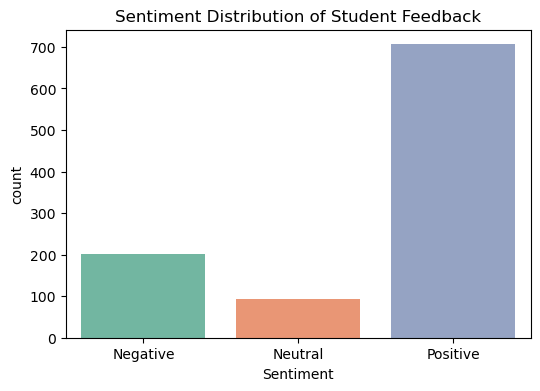

In [30]:
plt.figure(figsize=(6,4))
sns.countplot(x="Sentiment", data=df, palette="Set2")
plt.title("Sentiment Distribution of Student Feedback")
plt.show()

# Generating the Word Cloud

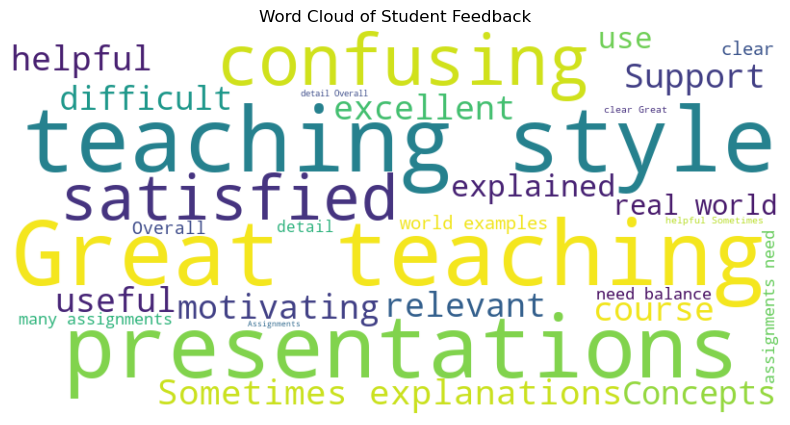

In [32]:
all_text = " ".join(df["Feedback Comments"])
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(all_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Student Feedback")
plt.show()



# Saving processed dataset 

In [34]:
df.to_csv("processed_student_feedback.csv", index=False)

# Showing sample with feedback + sentiment
df.head()


,Student ID,Well versed with the subject,Explains concepts in an understandable way,Use of presentations,Degree of difficulty of assignments,Solves doubts willingly,Structuring of the course,Provides support for students going above and beyond,Course recommendation based on relevance,Feedback Comments,Sentiment
0,340,5,2,7,6,9,2,1,8,Assignments were too difficult.,Negative
1,253,6,5,8,6,2,1,2,9,Concepts were explained in detail.,Neutral
2,680,7,7,6,5,4,2,3,1,"Overall, the course was relevant and useful.",Positive
3,806,9,6,7,1,5,9,4,6,Sometimes explanations were confusing.,Negative
4,632,8,10,8,4,6,6,9,9,Assignments were too difficult.,Negative


# Basic Statistics for Ratings

C:\Users\DELL\AppData\Local\Temp\ipykernel_20592\924054953.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_ratings.values, y=avg_ratings.index, palette="viridis")


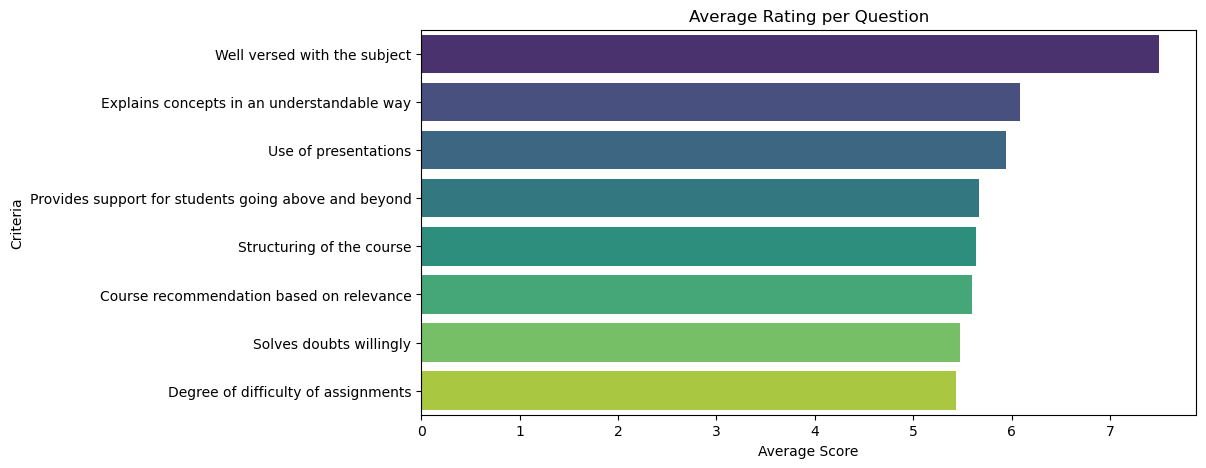

📊 Average Ratings:

Well versed with the subject                            7.497502
Explains concepts in an understandable way              6.081918
Use of presentations                                    5.942058
Provides support for students going above and beyond    5.662338
Structuring of the course                               5.636364
Course recommendation based on relevance                5.598402
Solves doubts willingly                                 5.474525
Degree of difficulty of assignments                     5.430569
dtype: float64


In [48]:
rating_columns = [
    'Well versed with the subject',
    'Explains concepts in an understandable way',
    'Use of presentations',
    'Degree of difficulty of assignments',
    'Solves doubts willingly',
    'Structuring of the course',
    'Provides support for students going above and beyond',
    'Course recommendation based on relevance'
]

# Mean rating per question
avg_ratings = df[rating_columns].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=avg_ratings.values, y=avg_ratings.index, palette="viridis")
plt.title("Average Rating per Question")
plt.xlabel("Average Score")
plt.ylabel("Criteria")
plt.show()

print("📊 Average Ratings:\n")
print(avg_ratings)


# Overall Satisfaction Score

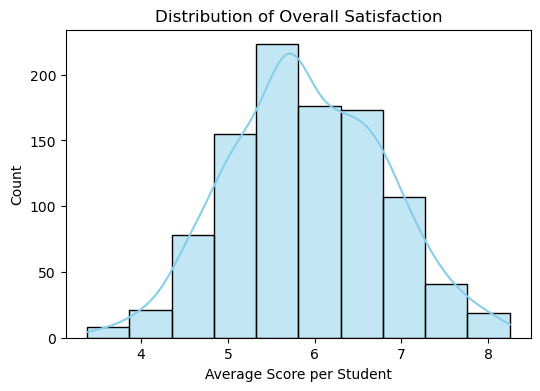

In [52]:
df["Overall Satisfaction"] = df[rating_columns].mean(axis=1)

plt.figure(figsize=(6,4))
sns.histplot(df["Overall Satisfaction"], bins=10, kde=True, color="skyblue")
plt.title("Distribution of Overall Satisfaction")
plt.xlabel("Average Score per Student")
plt.show()



# Correlation Heatmap

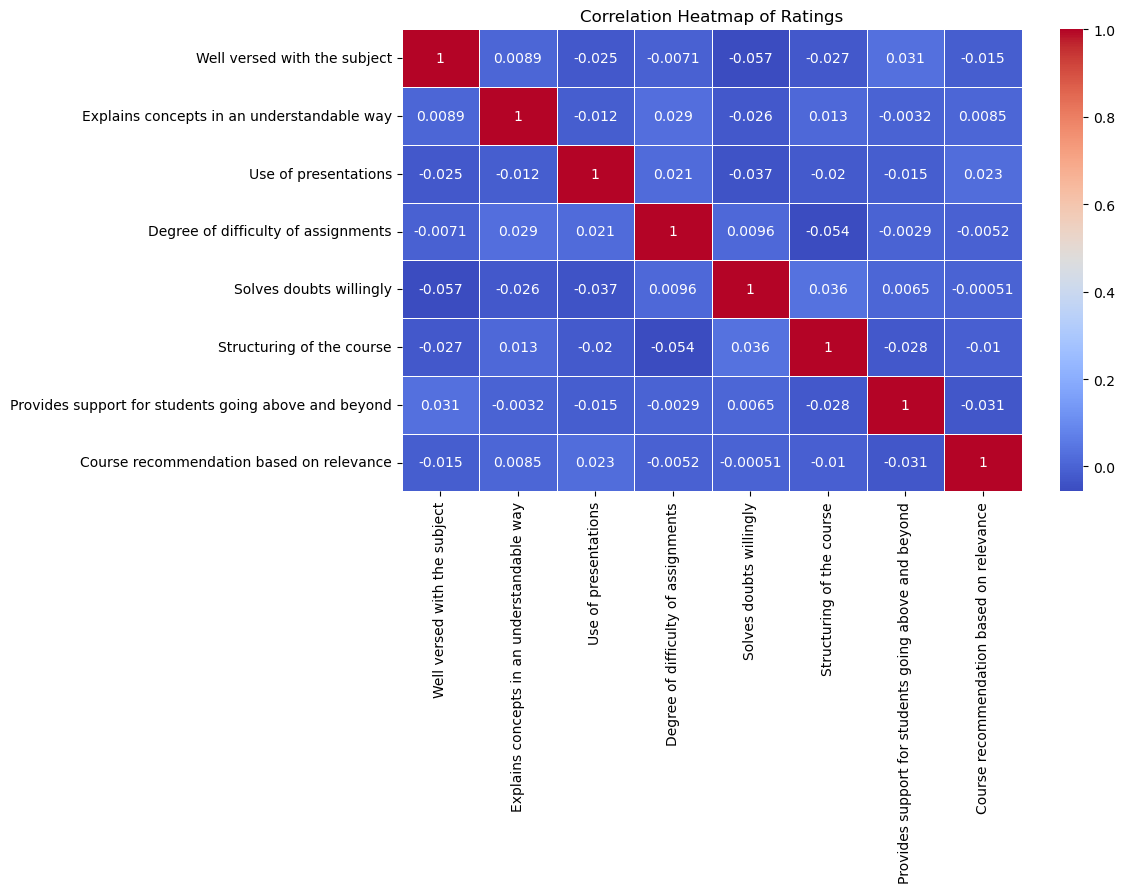

In [54]:
plt.figure(figsize=(10,6))
corr = df[rating_columns].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Ratings")
plt.show()

# Top Strengths & Areas to Improve

In [57]:
print("\n✅ Top 3 Strengths (Highest Avg Ratings):")
print(avg_ratings.head(3))

print("\n⚠️ Top 3 Areas to Improve (Lowest Avg Ratings):")
print(avg_ratings.tail(3))



✅ Top 3 Strengths (Highest Avg Ratings):
Well versed with the subject                  7.497502
Explains concepts in an understandable way    6.081918
Use of presentations                          5.942058
dtype: float64

⚠️ Top 3 Areas to Improve (Lowest Avg Ratings):
Course recommendation based on relevance    5.598402
Solves doubts willingly                     5.474525
Degree of difficulty of assignments         5.430569
dtype: float64
